In [1]:
# Import the required libraries. Add more as needed, e.g. for feature selection.

import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
import re
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
nltk.download('punkt')
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import matplotlib.pyplot as plt

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jmouk\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jmouk\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
# Read the train and test data from csv files to dataframes

train = pd.read_csv("new_train.csv", header = None, names = ['rating', 'review'])
test = pd.read_csv("new_test.csv", header = None, names = ['review'])

In [3]:
# This function takes a review as an input and returns the cleaned review

def CleanText(review):
    
    # convert the text to lower case 
    review = review.lower()
    
    # then remove unnecessary text (numbers, spaces etc.) from the reviews using regex
    review = re.sub(r'[^\w(\s+)]', '', review, flags = re.MULTILINE)
    
    # tokenize the words
    review_tokens = word_tokenize(review)
    
    # remove stop words
    stop_words_removed_review = [word for word in review_tokens if word not in stopwords.words('english')]
    
    # Apply stemming 
    s = PorterStemmer()
    cleaned_words = []
    for word in stop_words_removed_review:
        cleaned_words.append(s.stem(word))
    
    # Join the words to form a sentence and return it
    cleaned_review = " ".join(cleaned_words)
    
    return cleaned_review

In [4]:
# Apply the CleanText function to clean the reviews
train['review_cleaned'] = train['review'].apply(CleanText)
test['review_cleaned'] = test['review'].apply(CleanText)

In [143]:
train_ratings = train.values[:, 0]

In [237]:
# This function takes all train and test reviews as input and convert them to vectors using CountVectorizer or TfidfVectorizer
from sklearn.feature_selection import SelectKBest, f_classif

def text_feature_selector(train, test, train_ratings, k_value):
    
    # Initialize the CountVectorizer or TF-IDF vectorizer
    # Fit and transform the cleaned reviews of train using Vectorizer
    # Transform the cleaned review of test using the Vectorizer
    # After this step you will be left with train features and test features
    
    cv = CountVectorizer()
    train_cv = cv.fit_transform(train) 
    test_cv = cv.transform(test)

    # Next step is to select best features
    # Initialize feature selector
    feature_selector = SelectKBest(score_func=f_classif, k=k_value)
    
    # Fit and transform train features using the feature selector
    train_features =  feature_selector.fit_transform(train_cv, train_ratings)
    
    # Transform the test features using the feature selector
    test_features =  feature_selector.transform(test_cv)
    
    # finally return the transformed train and test features
    
    # return train features, test features
    return train_features, test_features

In [287]:
# This class implements the KNN algorithm
from collections import Counter

class KNN():
    def __init__(self, k = 9, similarity_function = 'euclidean'):
        
        self.k = k
        self.similarity_function = similarity_function
        # Try with at least two similarity functions and pass the similarity function accordingly while initializing the class object
    
    # Initialize the train and target
    def fit(self, train_features, train_ratings):
        self.train_features = train_features
        self.train_ratings = train_ratings
        
    # Predict the labels for test set using the nearest neighbors in train set
    def predict(self, test):
        self.test = test
        self.most_frequent_labels = []
        
        # implement the similarity function and return the most frequent label of the K nearest neighbors for each sample in the test set
        
        for test_feature in self.test:
            # see if similarity function is either cosine, or euclidean
            if(self.similarity_function == 'cosine'):
                distances = cosine_distance(test_feature, self.train_features.toarray())
            
            if(self.similarity_function == 'euclidean'):
                distances = euclidean_distance(test_feature.toarray(), self.train_features.toarray())
            
            # get indices of nearest neighbors
            indices = np.argsort(distances)[:self.k]
        
            # make prediction ie. get ratings
            predictions = []
            for index in indices:
                predictions.append(self.train_ratings[index])
        
            # find most common appearing rating
            self.most_frequent_labels.append(Counter(predictions).most_common(1)[0][0])
                  
        return self.most_frequent_labels
    
def cosine_distance(x1, x2):
    dot = np.dot(x1, x2)
    x1_norm = np.linalg.norm(x1)
    x2_norm = np.linalg.norm(x2)
    
    if(x1_norm == 0 or x2_norm == 0):
        return 0.0
    
    distance = dot / (x1_norm * x2_norm)
    return distance
    
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2, axis=1))

In [288]:
# Cross validation to find the best K value. You can also do this to find the best feature set.
# First shuffle the entire train data and divide it into k roughly equal sized folds 
# The training and evaluation process is repeated 'k' times, with each iteration using a different fold as the test set and the remaining k-1 folds as the training set.
# The K-nearest neighbors classifier is used to predict the labels of the test set using the remaining (k-1) folds as train.
# The cross validation function should return the best K value (here K stands for number of nearest neighbors)

def CrossValidation(train):
    
    shuffled_train = train.sample(frac=1).reset_index(drop=True) # shuffle train data (reset the indices after shuffling the data)
    shuffled_train_ratings = shuffled_train['rating'].values
    shuffled_train_features = shuffled_train['review'].values
    k_values = [4, 9, 15, 18, 26] # define a list of k values
    n_folds =  5 # define the number of folds
    accuracies = []
    
    #1) Divide the data into k folds (n_folds)
    first = 0
    increment = (len(shuffled_train)/n_folds) - 1
    last = int(first + increment)
    train_folds = []
    rating_folds = []
    
    for i in range(n_folds):
        train_folds.append(shuffled_train_features[first:last])
        rating_folds.append(shuffled_train_ratings[first:last])
        first = int(first + increment)
        last = int(last + increment)
    
    #2) After dividing the data into k folds,for each fold call text_feature_selector() 
    # to get the features of train folds and test fold
    
    for i in range (n_folds):
        if(i != 4):
            train_features, test_features = text_feature_selector(train_folds[i], train_folds[i + 1], rating_folds[i], k_values[i])
        else:
            train_features, test_features = text_feature_selector(train_folds[i], train_folds[i - 1], rating_folds[i], k_values[i])
        
        #3) Initialize and fit the KNN class and with the help of predict method in the KNN class, get the 
        # labels for the test fold
        classifier = KNN(k=k_values[i])
        
        #4) Each example in test fold has a target (rating), with the help of 
        # predicted label and target, find the accuracy for each fold
        classifier.fit(train_features, rating_folds[i])
        predictions = classifier.predict(test_features)
    
        #5) Find the average accuracy of all k-folds
        accuracy = np.sum(predictions == rating_folds[i]) / len(rating_folds[i])
        print(f'K = {k_values[i]} -> Accuracy of Fold {i}: {accuracy}')
        accuracies.append(accuracy)
        
    
    #Repeat the above steps for all values of k in k_values
    
    #Find the value of k for which the average accuracy of all folds is high compared to other k values and return it
    #Also return the average accuracy of k-folds for each value of k
    best_k_index = accuracies.index(max(accuracies))
    best_k = k_values[best_k_index]
    
    return best_k, accuracies, k_values

In [294]:
best_k, accuracies, k_values = CrossValidation(train)

K = 4 -> Accuracy of Fold 0: 0.504306751875521
K = 9 -> Accuracy of Fold 1: 0.5154209502639622
K = 15 -> Accuracy of Fold 2: 0.5054181717143651
K = 18 -> Accuracy of Fold 3: 0.5109752709085857
K = 26 -> Accuracy of Fold 4: 0.5034731869963879


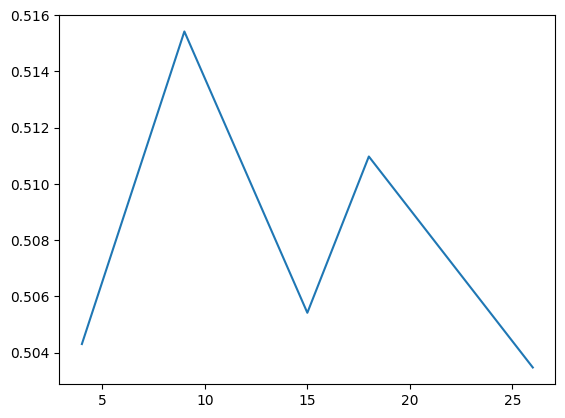

In [295]:
# Plot the accuracies (y-axis) vs k_values (x-axis) using matplotlib
plt.plot(k_values, accuracies)

In [296]:
# Initialize the KNN class with best_k value and predict the labels for test set using the entire train set
classifier = KNN(k=best_k)

train_features, test_features = text_feature_selector(train['review_cleaned'], test['review_cleaned'], train['rating'], best_k)
classifier.fit(train_features, train['rating'])
predictions = classifier.predict(test_features)

In [297]:
# Write the predicted labels of the test set to a .txt file and upload the .txt file to miner
file = open("predictions.txt", "a")

for prediction in predictions:
    file.write(str(prediction) + '\n')
file.close()